In [236]:
import xarray as xr
from pathlib import Path
import zarr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import geopandas as gpd

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import geopandas as gpd

from shapely.geometry import LineString
from shapely.ops import unary_union

In [ ]:
p = Path("/Users/drotto/src/jiflr/data/external/era5/era5_ncar-rda.zarr")
ds = xr.open_mfdataset(p, engine="zarr")
ds = ds.sel(time=ds.time.dt.month.isin([6, 7, 8]))  # select summer season for each year
ds

<xarray.Dataset> Size: 30GB
Dimensions:    (time: 17664, latitude: 33, longitude: 41, level: 37)
Coordinates:
  * latitude   (latitude) float64 264B 63.0 62.75 62.5 62.25 ... 55.5 55.25 55.0
  * level      (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * longitude  (longitude) float64 328B 220.0 220.2 220.5 ... 229.5 229.8 230.0
  * time       (time) datetime64[ns] 141kB 2017-06-01 ... 2024-08-31T23:00:00
Data variables: (12/30)
    BLH        (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    D          (time, level, latitude, longitude) float32 4GB dask.array<chunksize=(264, 1, 33, 41), meta=np.ndarray>
    FLSR       (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    FSR        (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    IE         (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    IEWS       (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    ...         ...
    VAR_10U    (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    VAR_10V    (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    VAR_2D     (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    VAR_2T     (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    W          (time, level, latitude, longitude) float32 4GB dask.array<chunksize=(264, 1, 33, 41), meta=np.ndarray>
    Z          (time, level, latitude, longitude) float32 4GB dask.array<chunksize=(264, 1, 33, 41), meta=np.ndarray>
Attributes:
    CONVERSION_DATE:      Thu Sep  5 11:04:55 MDT 2019
    CONVERSION_PLATFORM:  Linux r4i6n31 4.12.14-94.41-default #1 SMP Wed Oct ...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.1.6 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.3
    history:              Wed Jan 29 16:11:13 2025: /glade/u/apps/casper/23.1...

In [238]:
for var in ds.data_vars:
    try:
        print(f"{var}: {ds[var].attrs['long_name']}")
    except KeyError:
        print(f"{var}: no long_name attribute")

BLH: Boundary layer height
D: Divergence
FLSR: Forecast logarithm of surface roughness for heat
FSR: Forecast surface roughness
IE: Instantaneous moisture flux
IEWS: Instantaneous eastward turbulent surface stress
INSS: Instantaneous northward turbulent surface stress
ISHF: Instantaneous surface sensible heat flux
LCC: Low cloud cover
MSL: Mean sea level pressure
PV: Potential vorticity
Q: Specific humidity
SKT: Skin temperature
SP: Surface pressure
T: Temperature
TCC: Total cloud cover
TCW: Total column water
TCWV: Total column water vapour
U: U component of wind
U10N: Neutral wind at 10 m U-component
V: V component of wind
V10N: Neutral wind at 10 m V-component
VAR_100U: 100 metre U wind component
VAR_100V: 100 metre V wind component
VAR_10U: 10 metre U wind component
VAR_10V: 10 metre V wind component
VAR_2D: 2 metre dewpoint temperature
VAR_2T: 2 metre temperature
W: Vertical velocity
Z: Geopotential


In [239]:
# Define transects
main_transect = LineString(
    [
        (59.459528564092096, -135.3287066398975),  # Skagway
        (60.16984901240911, -134.70940256243654),  # Carcross
    ]
)

control_transect = LineString(
    [
        (58.30043883194991, -134.41922712082635),  # Juneau
        (59.57400, -133.70391),  # Atlin
    ]
)

In [240]:
# Load RGI glacier outlines
p = Path("/Users/drotto/src/jiflr/data/external/rgi7/RGI2000-v7.0-G-01_alaska")
rgi = gpd.read_file(p)

# Subset to map extent
rgi = rgi.cx[-136:-133.5, 58.25:60.25]
rgi = rgi.to_crs("EPSG:32608")  # UTM zone 8N

# Dissolve all geometries into one, then apply simplification
unified_geom = unary_union(rgi.geometry)
simplified_geom = unified_geom.buffer(750).buffer(-500).simplify(tolerance=100)

# Create new GeoDataFrame with simplified geometry
rgi = gpd.GeoDataFrame(geometry=[simplified_geom], crs="EPSG:32608")

# Convert back to PlateCarree
rgi = rgi.to_crs(crs=ccrs.PlateCarree())

# Convert back to PlateCarree
rgi = rgi.to_crs(crs=ccrs.PlateCarree())

<Axes: >

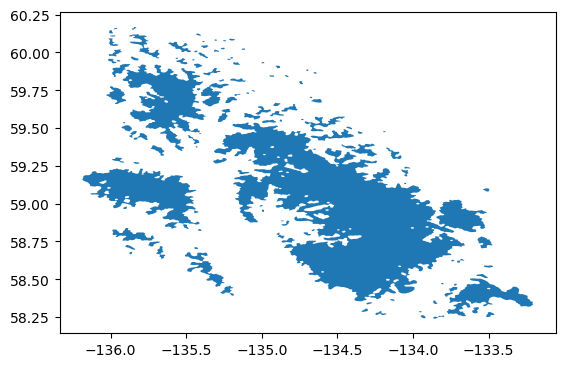

In [241]:
rgi.plot()

In [242]:
ds_mean = ds.mean(dim="time").compute()

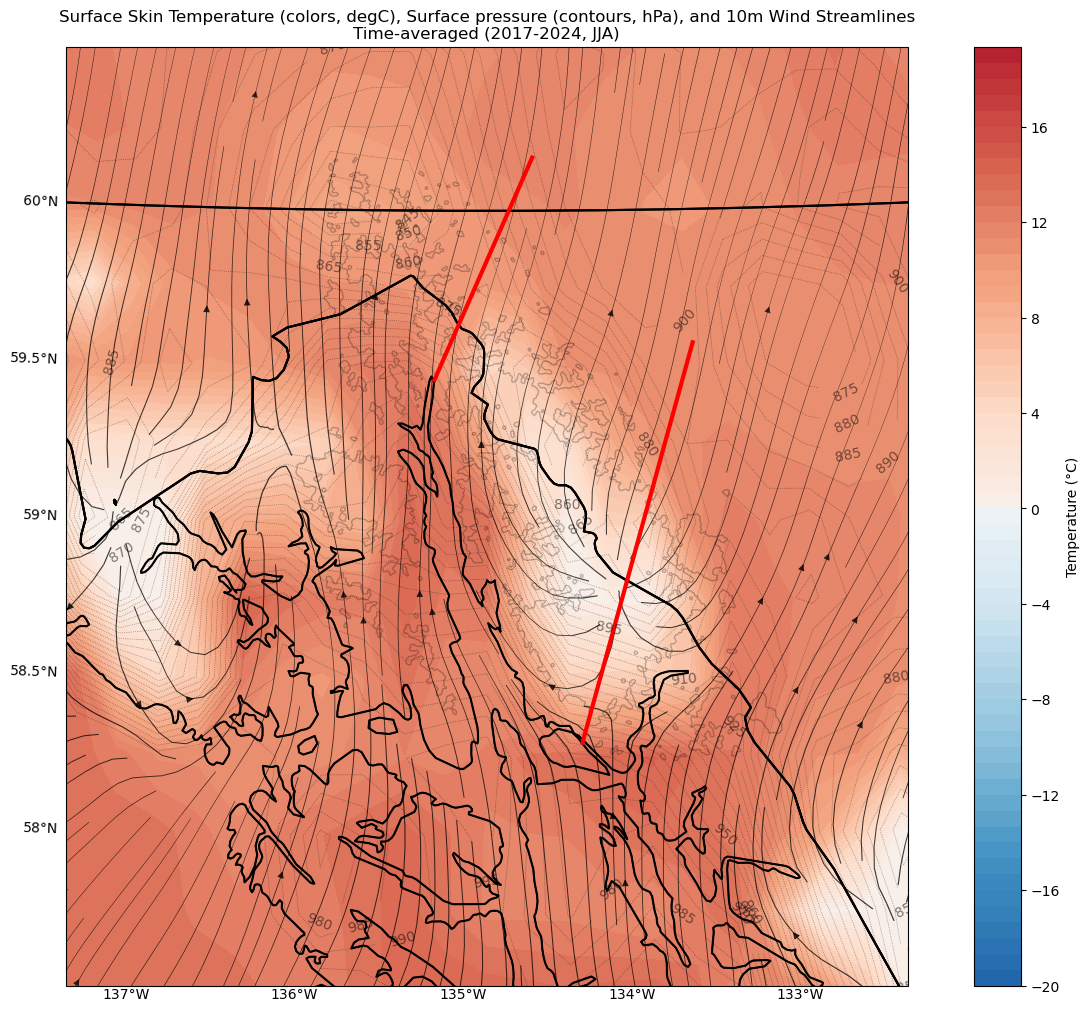

In [243]:
def plot_wind_temp_pressure(ds, lon_ext, lat_ext, buffer=1.0):

    # Add buffer to bounds
    lon_min_buff = lon_ext[0] - buffer
    lon_max_buff = lon_ext[1] + buffer
    lat_min_buff = lat_ext[0] - buffer
    lat_max_buff = lat_ext[1] + buffer

    # Create figure with cartopy projection
    fig = plt.figure(figsize=(15, 10), layout="constrained")

    proj = ccrs.LambertConformal(
        central_longitude=-135,  # or 225 if using your longitude system
        central_latitude=59,
        standard_parallels=(58, 60),
    )
    ax = plt.axes(projection=proj)

    # Plot glacier outlines
    rgi.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        alpha=0.25,
        lw=1,
        ec="#000",
        color="none",
        zorder=1.9,
    )

    # Plot transects
    # Main transect (Skagway-Carcross)
    y, x = zip(*main_transect.coords)
    ax.plot(x, y, lw=3, c="red", marker="", transform=ccrs.PlateCarree(), zorder=3)

    # Control transect (Juneau-Atlin)
    y, x = zip(*control_transect.coords)
    ax.plot(x, y, lw=3, c="red", marker="", transform=ccrs.PlateCarree(), zorder=3)

    # Add transect labels
    # ax.text(-134.07, 59.14804, "Icefield Transect", fontsize=8, rotation=76,
    #         fontweight="bold", transform=ccrs.PlateCarree())
    # ax.text(-135.1289, 59.8004, "Ice-free Transect", fontsize=8, rotation=66,
    #         fontweight="bold", transform=ccrs.PlateCarree())

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=1.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=1.5, edgecolor="black")

    # Add gridlines
    gl = ax.gridlines(
        draw_labels=True,
        ms=True,
        x_inline=False,
        y_inline=False,
    )
    gl.top_labels = False  # remove top labels
    gl.right_labels = False  # remove right labels
    gl.xlines = False  # hide vertical gridlines
    gl.ylines = False  # hide horizontal gridlines
    gl.xlabel_style = {
        "rotation": 0,
    }  # make bottom labels horizontal

    # Get data for the specific time and convert to numpy arrays
    temp = ds.SKT.values - 273.15  # Convert K to C
    u_wind = ds.VAR_10U.values
    v_wind = ds.VAR_10V.values
    pressure = ds.SP.values / 100  # Convert Pa to hPa

    # Create lat/lon meshgrid
    lon, lat = np.meshgrid(ds.longitude.values, ds.latitude.values)

    # mymap = mcolors.LinearSegmentedColormap.from_list("freezing_split", colors)
    bwr = plt.get_cmap("RdBu_r")
    cmap = mcolors.ListedColormap(
        np.concatenate(
            [
                bwr((np.linspace(0.1, 0.475, 100))),
                bwr((np.linspace(0.525, 0.9, 100))),
            ]
        )
    )

    # Modify the temperature plotting part
    vcenter = 0
    halfrange = np.ceil(np.max(np.abs(temp)) / 10) * 10
    temp_levels = np.arange(
        vcenter - halfrange, vcenter + halfrange, 2 * halfrange / 60
    )
    norm = mcolors.CenteredNorm(vcenter=vcenter, halfrange=halfrange)
    cf = ax.contourf(
        lon,
        lat,
        temp,
        levels=temp_levels,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
    )
    plt.colorbar(cf, label="Temperature (°C)")

    # Plot pressure contours
    press_levels = np.arange(800, 1000, 5)
    cs = ax.contour(
        lon,
        lat,
        pressure,
        levels=press_levels,
        colors="black",
        alpha=0.5,
        linewidths=0.5,
        linestyles="dotted",
        transform=ccrs.PlateCarree(),
    )
    plt.clabel(cs, fmt="%1.0f")

    # Plot wind vectors (subsample for clarity)
    # skip = 1  # Adjust this value to change vector density
    # ax.quiver(lon[::skip, ::skip], lat[::skip, ::skip],
    #           u_wind[::skip, ::skip], v_wind[::skip, ::skip],
    #           transform=ccrs.PlateCarree(),
    #           scale=150, width=0.003, color='gray')

    # Plot streamlines
    n = 10  # adjust this to change density
    start_x, start_y = np.meshgrid(lon[::n], lat[::n])
    start_points = np.column_stack((start_x.flatten(), start_y.flatten()))
    speed = np.sqrt(u_wind**2 + v_wind**2)
    lw = 1 * (1 - speed / speed.max())
    ax.streamplot(
        lon,
        lat,
        u_wind,
        v_wind,
        transform=ccrs.PlateCarree(),
        color=(0, 0, 0, 0.75),
        linewidth=lw,
        arrowsize=1,
        density=4,  # Adjust density of streamlines
        # density=1,  # Adjust density of streamlines
        # start_points=start_points,
        broken_streamlines=True,
    )

    # Add this after the other plotting commands
    # Approximate bounds of the Juneau Icefield
    icefield_bounds = {
        "lon_min": 224.5,  # ~134.2°W
        "lon_max": 226.5,  # ~133.2°W
        "lat_min": 58.25,  # ~58.5°N
        "lat_max": 59.5,  # ~59.5°N
    }

    # Set map extent
    ax.set_extent(
        [lon_ext[0], lon_ext[1], lat_ext[0], lat_ext[1]], crs=ccrs.PlateCarree()
    )

    return fig


# Create plot for most recent timestep

fig = plot_wind_temp_pressure(ds_mean, lon_ext=(222.5, 227.5), lat_ext=(57.5, 60.5))
# Add timestamp title
plt.title(
    f"Surface Skin Temperature (colors, degC), Surface pressure (contours, hPa), and 10m Wind Streamlines\nTime-averaged ({pd.Timestamp(ds.time.values[0]):%Y}-{pd.Timestamp(ds.time.values[-1]):%Y}, JJA)"
)
plt.show()

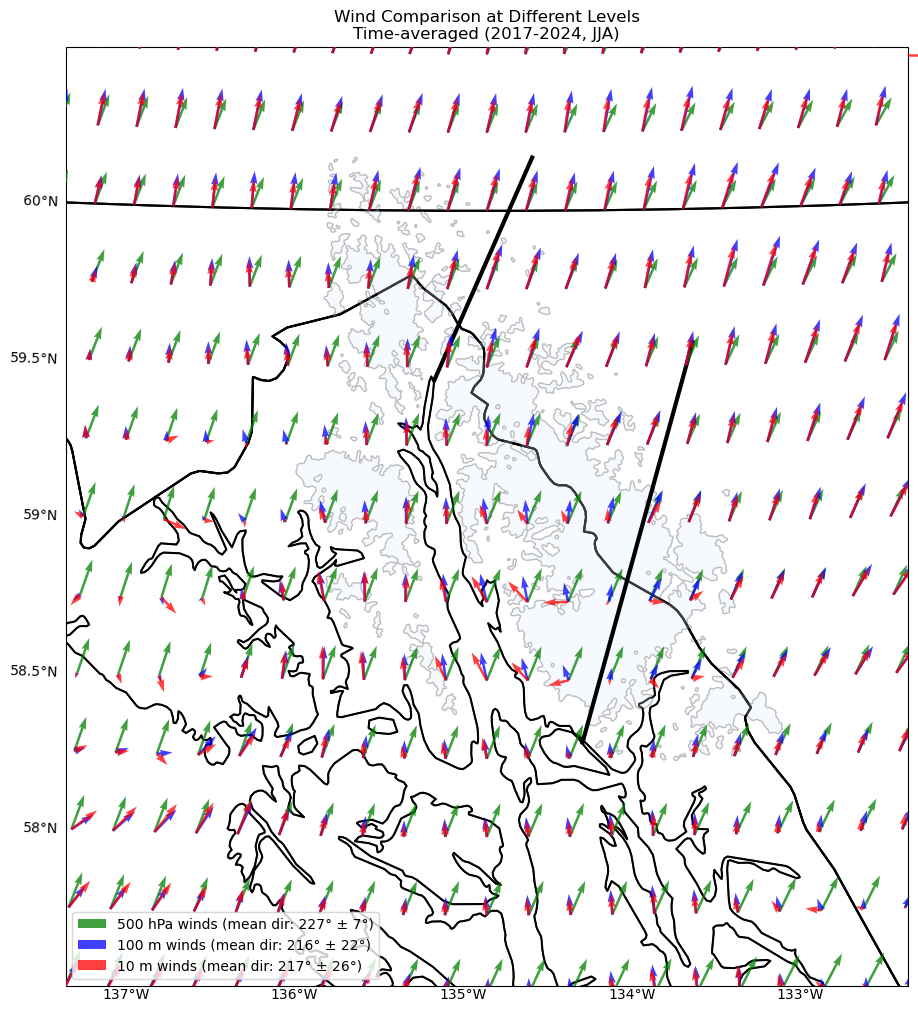

In [ ]:
def plot_wind_temp_pressure(ds, lon_ext, lat_ext, buffer=1.0):
    # Add buffer to bounds
    lon_min_buff = lon_ext[0] - buffer
    lon_max_buff = lon_ext[1] + buffer
    lat_min_buff = lat_ext[0] - buffer
    lat_max_buff = lat_ext[1] + buffer

    # Create figure with cartopy projection
    fig = plt.figure(figsize=(15, 10), layout="constrained")

    proj = ccrs.LambertConformal(
        central_longitude=-135,
        central_latitude=59,
        standard_parallels=(58, 60),
    )
    ax = plt.axes(projection=proj)

    # Plot glacier outlines
    rgi.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        alpha=0.25,
        lw=1,
        ec="#000",
        color=(220 / 255, 236 / 255, 255 / 255, 0.75),
        zorder=1.9,
    )

    # Plot transects
    y, x = zip(*main_transect.coords)
    ax.plot(x, y, lw=3, c="black", marker="", transform=ccrs.PlateCarree(), zorder=3)
    y, x = zip(*control_transect.coords)
    ax.plot(x, y, lw=3, c="black", marker="", transform=ccrs.PlateCarree(), zorder=3)

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=1.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=1.5, edgecolor="black")

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, ms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False
    gl.ylines = False
    gl.xlabel_style = {"rotation": 0}

    # Get data and create lat/lon meshgrid
    lon, lat = np.meshgrid(ds.longitude.values, ds.latitude.values)

    skip = 1  # Adjust for vector density

    def get_wind_stats(u, v):
        speed = np.sqrt(u**2 + v**2)
        direction = (270 - np.degrees(np.arctan2(v, u))) % 360

        # Calculate mean direction using vector averaging
        u_mean = np.mean(u)
        v_mean = np.mean(v)
        mean_dir = (270 - np.degrees(np.arctan2(v_mean, u_mean))) % 360

        # Calculate temporal standard deviation at each point
        dir_rad = np.radians((90 - direction) % 360)
        R = np.sqrt(
            np.mean(np.cos(dir_rad), axis=0) ** 2
            + np.mean(np.sin(dir_rad), axis=0) ** 2
        )
        std_dir = np.degrees(np.sqrt(-2 * np.log(R)))

        # Average the standard deviations across spatial points
        mean_std_dir = np.mean(std_dir)

        scale = np.max(speed) * 15

        return speed, scale, mean_dir, mean_std_dir

    # 500 hPa winds (green)
    u500 = ds.sel(level=500).U.values
    v500 = ds.sel(level=500).V.values
    speed500, scale500, mean_dir500, std_dir500 = get_wind_stats(u500, v500)
    q500 = ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u500[::skip, ::skip],
        v500[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=scale500,
        width=0.003,
        color="green",
        alpha=0.75,
        zorder=3,
        minshaft=1,
        label=f"500 hPa winds (mean dir: {mean_dir500:.0f}° ± {std_dir500:.0f}°)",
    )

    # 100 m winds (blue)
    u100 = ds["VAR_100U"].values
    v100 = ds["VAR_100V"].values
    speed100, scale100, mean_dir100, std_dir100 = get_wind_stats(u100, v100)
    q100 = ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u100[::skip, ::skip],
        v100[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=scale100,
        width=0.003,
        color="blue",
        alpha=0.75,
        zorder=3,
        minshaft=1,
        label=f"100 m winds (mean dir: {mean_dir100:.0f}° ± {std_dir100:.0f}°)",
    )

    # 10m winds (red)
    u10 = ds.VAR_10U.values
    v10 = ds.VAR_10V.values
    speed10, scale10, mean_dir10, std_dir10 = get_wind_stats(u10, v10)
    q10 = ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u10[::skip, ::skip],
        v10[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=scale10,
        width=0.003,
        color="red",
        alpha=0.75,
        zorder=3,
        minshaft=1,
        label=f"10 m winds (mean dir: {mean_dir10:.0f}° ± {std_dir10:.0f}°)",
    )

    # Add quiverkeys for scale reference
    ref_speed = 10  # Reference speed for scale arrows
    ax.quiverkey(
        q10,
        0.95,
        0.95,
        ref_speed,
        f"{ref_speed} m/s (10 m)",
        labelpos="E",
        coordinates="figure",
        color="red",
    )
    ax.quiverkey(
        q100,
        0.95,
        0.90,
        ref_speed,
        f"{ref_speed} m/s (100 m)",
        labelpos="E",
        coordinates="figure",
        color="blue",
    )
    ax.quiverkey(
        q500,
        0.95,
        0.85,
        ref_speed,
        f"{ref_speed} m/s (500 hPa)",
        labelpos="E",
        coordinates="figure",
        color="green",
    )
    # Add legend
    ax.legend(loc="lower left")

    # Set map extent
    ax.set_extent(
        [lon_ext[0], lon_ext[1], lat_ext[0], lat_ext[1]], crs=ccrs.PlateCarree()
    )

    return fig


# Create plot
fig = plot_wind_temp_pressure(ds_mean, lon_ext=(222.5, 227.5), lat_ext=(57.5, 60.5))
plt.title(
    f"Wind Comparison at Different Levels\n"
    + f"Time-averaged ({pd.Timestamp(ds.time.values[0]):%Y}-{pd.Timestamp(ds.time.values[-1]):%Y}, JJA)"
)
plt.show()

In [ ]:
ds.sel(level=750).U.dropna(dim="time").values.shape

(2208, 33, 41)

Text(0.5, 1.0, 'Wind Comparison at Different Pressure Levels\nTime-averaged (2024, JJA)')

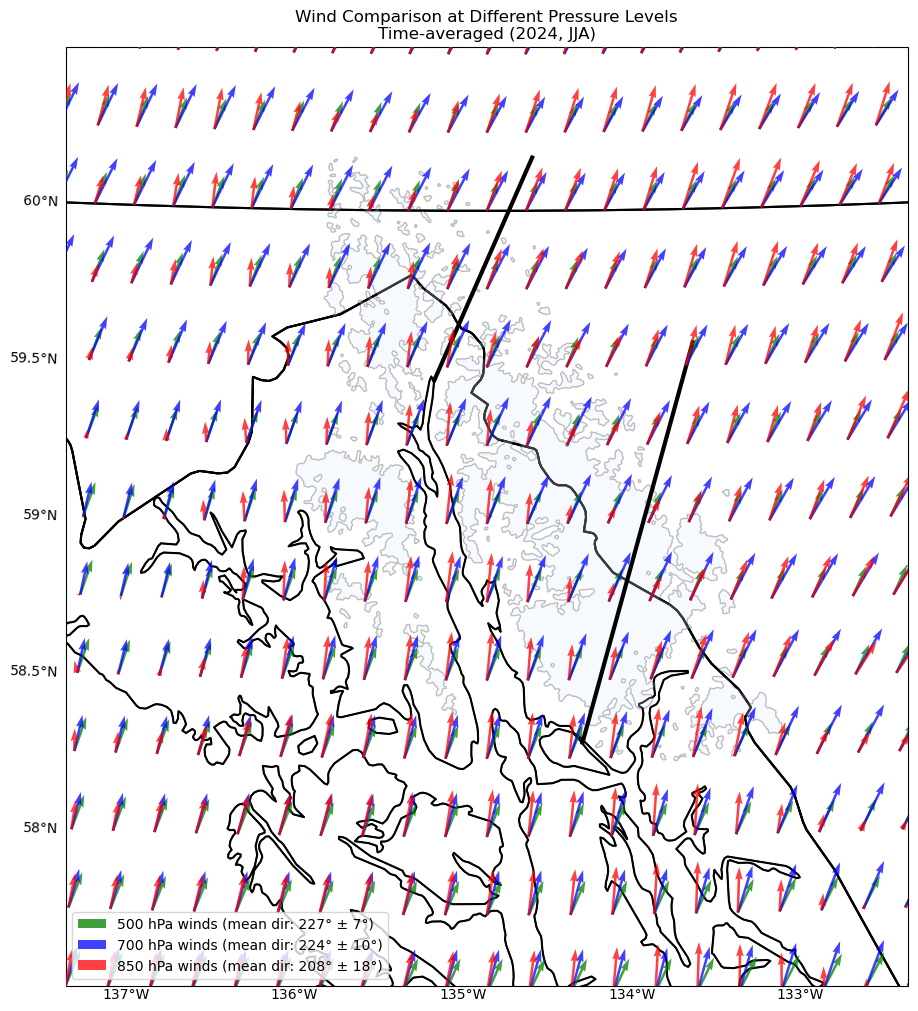

In [261]:
def plot_wind_temp_pressure(ds, lon_ext, lat_ext, buffer=1.0):
    # Add buffer to bounds
    lon_min_buff = lon_ext[0] - buffer
    lon_max_buff = lon_ext[1] + buffer
    lat_min_buff = lat_ext[0] - buffer
    lat_max_buff = lat_ext[1] + buffer

    # Create figure with cartopy projection
    fig = plt.figure(figsize=(15, 10), layout="constrained")

    proj = ccrs.LambertConformal(
        central_longitude=-135,
        central_latitude=59,
        standard_parallels=(58, 60),
    )
    ax = plt.axes(projection=proj)

    # Plot glacier outlines
    rgi.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        alpha=0.25,
        lw=1,
        ec="#000",
        color=(220 / 255, 236 / 255, 255 / 255, 0.75),
        zorder=1.9,
    )

    # Plot transects
    y, x = zip(*main_transect.coords)
    ax.plot(x, y, lw=3, c="black", marker="", transform=ccrs.PlateCarree(), zorder=3)
    y, x = zip(*control_transect.coords)
    ax.plot(x, y, lw=3, c="black", marker="", transform=ccrs.PlateCarree(), zorder=3)

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=1.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=1.5, edgecolor="black")

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, ms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False
    gl.ylines = False
    gl.xlabel_style = {"rotation": 0}

    # Get data and create lat/lon meshgrid
    lon, lat = np.meshgrid(ds.longitude.values, ds.latitude.values)

    skip = 1  # Adjust for vector density

    def get_wind_stats(u, v):
        speed = np.sqrt(u**2 + v**2)
        direction = (270 - np.degrees(np.arctan2(v, u))) % 360

        # Calculate mean direction using vector averaging
        u_mean = np.mean(u)
        v_mean = np.mean(v)
        mean_dir = (270 - np.degrees(np.arctan2(v_mean, u_mean))) % 360

        # Calculate temporal standard deviation at each point
        dir_rad = np.radians((90 - direction) % 360)
        R = np.sqrt(
            np.mean(np.cos(dir_rad), axis=0) ** 2
            + np.mean(np.sin(dir_rad), axis=0) ** 2
        )
        std_dir = np.degrees(np.sqrt(-2 * np.log(R)))

        # Average the standard deviations across spatial points
        mean_std_dir = np.mean(std_dir)

        scale = np.max(speed) * 15

        return speed, scale, mean_dir, mean_std_dir

    # 500 hPa winds (green)
    u500 = ds.sel(level=500).U.values
    v500 = ds.sel(level=500).V.values
    speed500, scale500, mean_dir500, std_dir500 = get_wind_stats(u500, v500)
    q500 = ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u500[::skip, ::skip],
        v500[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=scale500,
        width=0.003,
        color="green",
        alpha=0.75,
        zorder=3.1,
        minshaft=1,
        label=f"500 hPa winds (mean dir: {mean_dir500:.0f}° ± {std_dir500:.0f}°)",
    )

    # 700 hPa winds (blue)
    u700 = ds.sel(level=700).U.values
    v700 = ds.sel(level=700).V.values
    speed700, scale700, mean_dir700, std_dir700 = get_wind_stats(u700, v700)
    q700 = ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u700[::skip, ::skip],
        v700[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=scale700,
        width=0.003,
        color="blue",
        alpha=0.75,
        zorder=3.2,
        minshaft=1,
        label=f"700 hPa winds (mean dir: {mean_dir700:.0f}° ± {std_dir700:.0f}°)",
    )

    # 850 hPa winds (red)
    u850 = ds.sel(level=850).U.values
    v850 = ds.sel(level=850).V.values
    speed850, scale850, mean_dir850, std_dir850 = get_wind_stats(u850, v850)
    q850 = ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u850[::skip, ::skip],
        v850[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=scale850,
        width=0.003,
        color="red",
        alpha=0.75,
        zorder=3.3,
        minshaft=1,
        label=f"850 hPa winds (mean dir: {mean_dir850:.0f}° ± {std_dir850:.0f}°)",
    )

    # Add quiverkeys for scale reference
    ref_speed = 10  # Reference speed for scale arrows
    ax.quiverkey(
        q850,
        0.95,
        0.95,
        ref_speed,
        f"{ref_speed} m/s (850 hPa)",
        labelpos="E",
        coordinates="figure",
        color="red",
    )
    ax.quiverkey(
        q700,
        0.95,
        0.90,
        ref_speed,
        f"{ref_speed} m/s (700 hPa)",
        labelpos="E",
        coordinates="figure",
        color="blue",
    )
    ax.quiverkey(
        q500,
        0.95,
        0.85,
        ref_speed,
        f"{ref_speed} m/s (500 hPa)",
        labelpos="E",
        coordinates="figure",
        color="green",
    )
    # Add legend
    ax.legend(loc="lower left")

    # Set map extent
    ax.set_extent(
        [lon_ext[0], lon_ext[1], lat_ext[0], lat_ext[1]], crs=ccrs.PlateCarree()
    )

    return fig


# Create plot
fig = plot_wind_temp_pressure(ds_mean, lon_ext=(222.5, 227.5), lat_ext=(57.5, 60.5))
plt.title(
    f"Wind Comparison at Different Pressure Levels\n" + f"Time-averaged (2024, JJA)"
)

In [245]:
u500 = ds.sel(level=500)["U"].dropna(dim="time")
u500

<xarray.DataArray 'U' (time: 2208, latitude: 33, longitude: 41)> Size: 12MB
dask.array<getitem, shape=(2208, 33, 41), dtype=float32, chunksize=(336, 33, 41), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 264B 63.0 62.75 62.5 62.25 ... 55.5 55.25 55.0
    level      float64 8B 500.0
  * longitude  (longitude) float64 328B 220.0 220.2 220.5 ... 229.5 229.8 230.0
  * time       (time) datetime64[ns] 18kB 2024-06-01 ... 2024-08-31T23:00:00
Attributes: (12/14)
    QuantizeBitGroomNumberOfSignificantDigits:  7
    ecmwf_local_table:                          128
    ecmwf_parameter:                            131
    grid_specification:                         0.25 degree x 0.25 degree fro...
    long_name:                                  U component of wind
    maximum_value:                              108.94619750976562
    ...                                         ...
    rda_dataset:                                ds633.0
    rda_dataset_doi:                            DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                          ERA5 atmospheric pressure lev...
    rda_dataset_url:                            https:/rda.ucar.edu/datasets/...
    short_name:                                 u
    units:                                      m s**-1

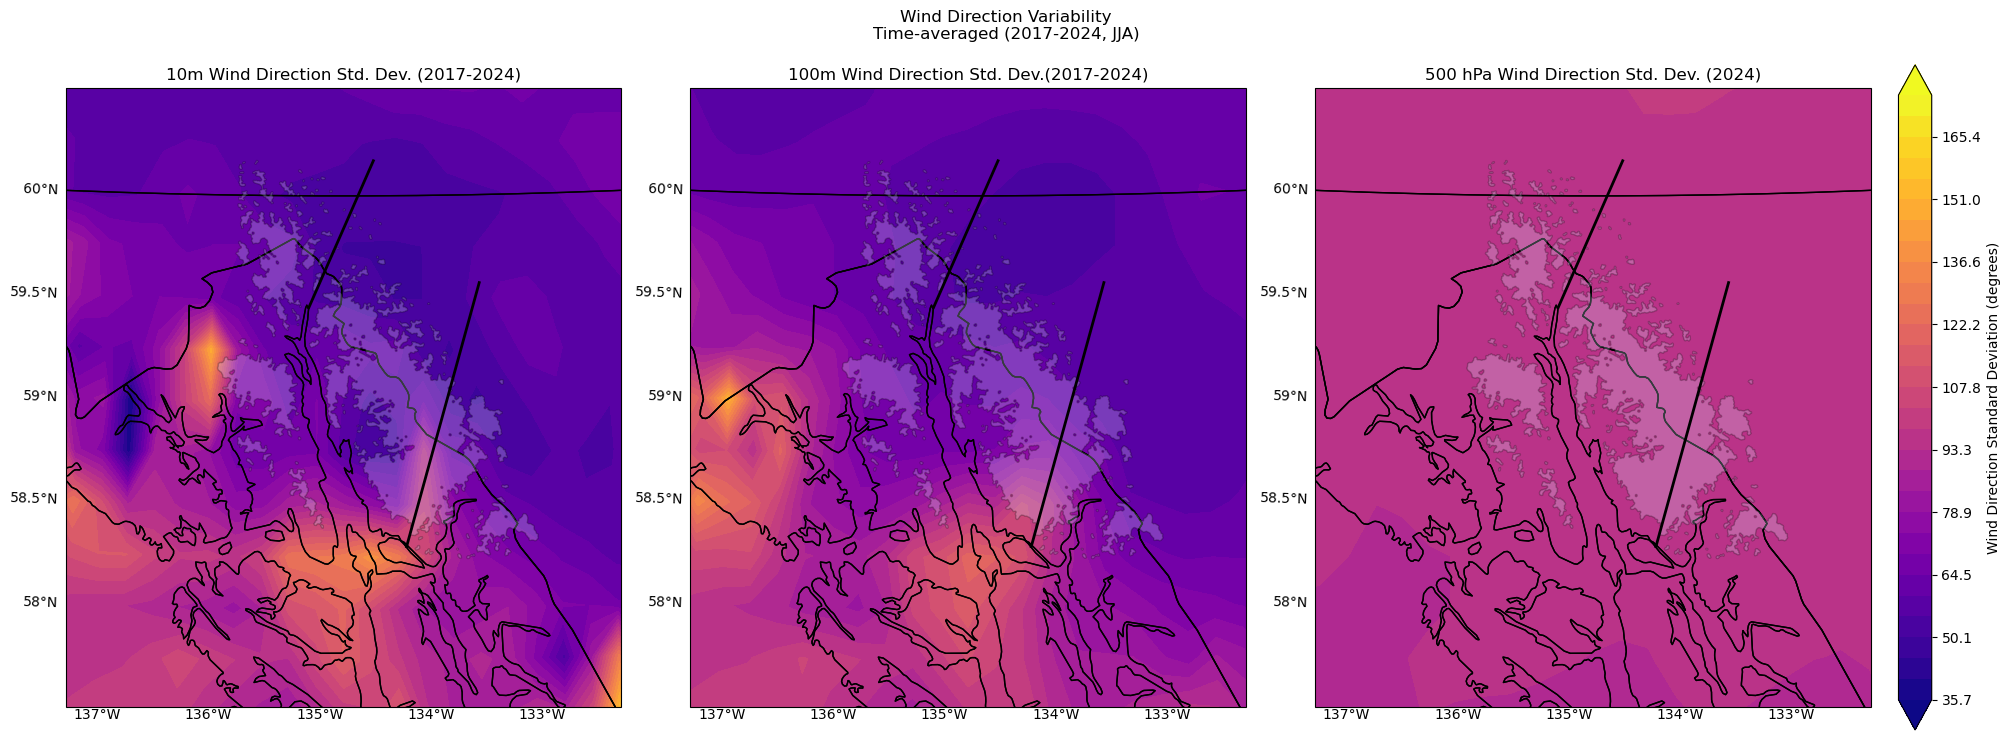

In [246]:
def plot_wind_direction_variability(ds, lon_ext, lat_ext, buffer=1.0):
    # Add buffer to bounds
    lon_min_buff = lon_ext[0] - buffer
    lon_max_buff = lon_ext[1] + buffer
    lat_min_buff = lat_ext[0] - buffer
    lat_max_buff = lat_ext[1] + buffer

    # Create figure with cartopy projection and 3 subplots
    fig = plt.figure(figsize=(20, 7), layout="constrained")

    proj = ccrs.LambertConformal(
        central_longitude=-135,
        central_latitude=59,
        standard_parallels=(58, 60),
    )

    def calculate_directional_std_over_time(u, v):
        """Calculate directional standard deviation over time at each grid point"""
        # Calculate direction in mathematical angle (radians)
        direction = np.arctan2(v, u)  # direction will have shape (time, lat, lon)

        # Calculate mean cos and sin components over time
        mean_cos = np.mean(np.cos(direction), axis=0)
        mean_sin = np.mean(np.sin(direction), axis=0)

        # Calculate R (mean resultant length) for each grid point
        R = np.sqrt(mean_cos**2 + mean_sin**2)

        # Convert to standard deviation in degrees
        return np.degrees(np.sqrt(-2 * np.log(R)))

    # Get data and create lat/lon meshgrid
    lon, lat = np.meshgrid(ds.longitude.values, ds.latitude.values)

    # Calculate directional variability for each level
    titles = [
        "10m Wind Direction Std. Dev. (2017-2024)",
        "100m Wind Direction Std. Dev.(2017-2024)",
        "500 hPa Wind Direction Std. Dev. (2024)",
    ]

    # Calculate standard deviations for each level
    std_10m = calculate_directional_std_over_time(ds.VAR_10U.values, ds.VAR_10V.values)
    std_100m = calculate_directional_std_over_time(
        ds["VAR_100U"].values, ds["VAR_100V"].values
    )
    std_500 = calculate_directional_std_over_time(
        ds.sel(level=500).U.dropna(dim="time").values,
        ds.sel(level=500).V.dropna(dim="time").values,
    )

    # Create color normalization shared across all plots
    vmin = min(np.nanmin(std_10m), np.nanmin(std_100m), np.nanmin(std_500))
    vmax = max(np.nanmax(std_10m), np.nanmax(std_100m), np.nanmax(std_500))
    norm = plt.Normalize(vmin, vmax)

    # Create subplots
    for idx, (data, title) in enumerate(
        [(std_10m, titles[0]), (std_100m, titles[1]), (std_500, titles[2])]
    ):
        ax = fig.add_subplot(1, 3, idx + 1, projection=proj)

        # Plot glacier outlines
        rgi.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            alpha=0.25,
            lw=1,
            ec="#000",
            color=(220 / 255, 236 / 255, 255 / 255, 0.75),
            zorder=1.9,
        )

        # Plot transects
        y, x = zip(*main_transect.coords)
        ax.plot(x, y, lw=2, c="black", transform=ccrs.PlateCarree(), zorder=3)
        y, x = zip(*control_transect.coords)
        ax.plot(x, y, lw=2, c="black", transform=ccrs.PlateCarree(), zorder=3)

        # Add map features
        ax.coastlines()
        ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=1)
        ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=1)

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlines = False
        gl.ylines = False
        gl.xlabel_style = {"rotation": 0}

        # Plot directional variability
        im = ax.contourf(
            lon,
            lat,
            data,
            levels=np.linspace(vmin, vmax, 30),
            transform=ccrs.PlateCarree(),
            cmap="plasma",  # Yellow-Orange-Red colormap
            norm=norm,
            extend="both",
        )

        # Set map extent
        ax.set_extent(
            [lon_ext[0], lon_ext[1], lat_ext[0], lat_ext[1]], crs=ccrs.PlateCarree()
        )

        ax.set_title(title)

    # Add colorbar
    plt.colorbar(im, label="Wind Direction Standard Deviation (degrees)")

    return fig


# Create plot
fig = plot_wind_direction_variability(ds, lon_ext=(222.5, 227.5), lat_ext=(57.5, 60.5))
plt.suptitle(
    f"Wind Direction Variability\n"
    + f"Time-averaged ({pd.Timestamp(ds.time.values[0]):%Y}-{pd.Timestamp(ds.time.values[-1]):%Y}, JJA)",
    y=1.05,
)
plt.show()

In [247]:
500

500

In [248]:
print(
    f"Temperature (colors), Pressure (contours), and 10m Wind streamlines\nTime-averaged ({pd.Timestamp(ds.time.values[0]):%Y}-{pd.Timestamp(ds.time.values[-1]):%Y}, MJJASO)"
)
# mlines\nTime-averaged ({ds.time[0].}-{ds.time[-1]}")

Temperature (colors), Pressure (contours), and 10m Wind streamlines
Time-averaged (2017-2024, MJJASO)


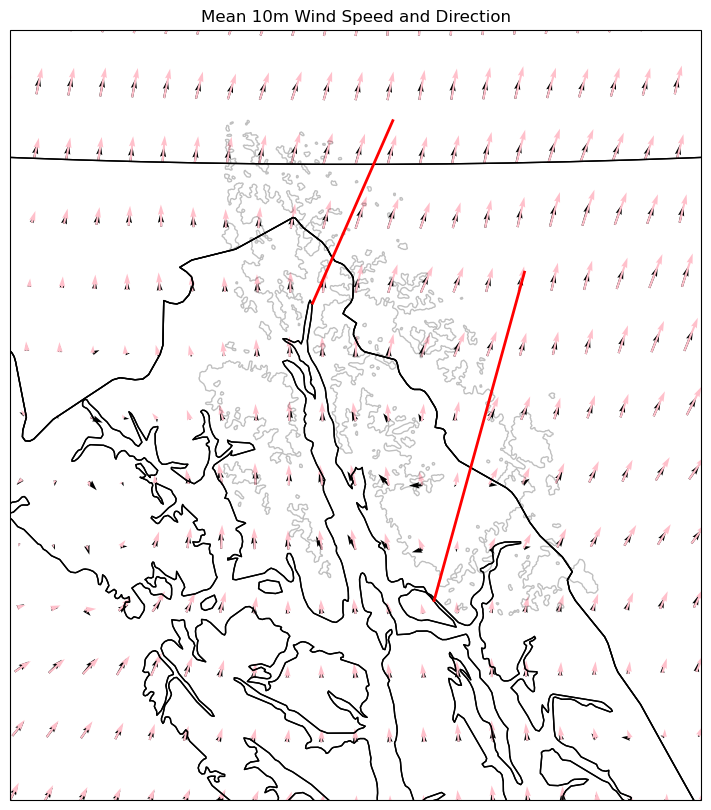

In [249]:
def plot_wind_direction(ds, lon_ext, lat_ext, buffer=1.0):
    # Add buffer to bounds
    lon_min_buff = lon_ext[0] - buffer
    lon_max_buff = lon_ext[1] + buffer
    lat_min_buff = lat_ext[0] - buffer
    lat_max_buff = lat_ext[1] + buffer

    # Create figure with cartopy projection
    fig = plt.figure(figsize=(15, 10))

    proj = ccrs.LambertConformal(
        central_longitude=-135,
        central_latitude=59,
        standard_parallels=(58, 60),
    )
    ax = plt.axes(projection=proj)

    # Plot glacier outlines
    rgi.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        alpha=0.25,
        lw=1,
        ec="#000",
        color="none",
        zorder=1.9,
    )

    # Plot transects
    y, x = zip(*main_transect.coords)
    ax.plot(x, y, lw=2, c="red", marker="", transform=ccrs.PlateCarree(), zorder=2)
    y, x = zip(*control_transect.coords)
    ax.plot(x, y, lw=2, c="red", marker="", transform=ccrs.PlateCarree(), zorder=2)

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=1, edgecolor="black")
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=1, edgecolor="black")

    # Get wind data
    u_wind = ds.VAR_10U.values
    v_wind = ds.VAR_10V.values

    u_wind100 = ds.VAR_100U.values
    v_wind100 = ds.VAR_100V.values

    # Create lat/lon meshgrid
    lon, lat = np.meshgrid(ds.longitude.values, ds.latitude.values)

    # Calculate wind speed and direction
    speed = np.sqrt(u_wind**2 + v_wind**2)

    # Create colormap for wind speed
    speed_levels = np.linspace(0, np.percentile(speed, 98), 20)

    # # Plot wind speed as background color
    # cf = ax.contourf(
    #     lon,
    #     lat,
    #     speed,
    #     levels=speed_levels,
    #     transform=ccrs.PlateCarree(),
    #     cmap='YlOrRd',
    #     extend='max'
    # )
    # plt.colorbar(cf, label="Wind Speed (m/s)")

    # Add wind barbs (optional, can be commented out if too cluttered)

    # Plot wind vectors (subsample for clarity)
    skip = 1  # Adjust this value to change vector density
    ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u_wind[::skip, ::skip],
        v_wind[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=50,
        width=0.003,
        color="black",
    )

    ax.quiver(
        lon[::skip, ::skip],
        lat[::skip, ::skip],
        u_wind100[::skip, ::skip],
        v_wind100[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=50,
        width=0.003,
        color="pink",
    )

    # Set map extent
    ax.set_extent(
        [lon_ext[0], lon_ext[1], lat_ext[0], lat_ext[1]], crs=ccrs.PlateCarree()
    )

    return fig


# Create plot for time-averaged data
ds_mean = ds.mean(dim="time").compute()
fig = plot_wind_direction(ds_mean, lon_ext=(222.5, 227.5), lat_ext=(57.5, 60.5))
plt.title("Mean 10m Wind Speed and Direction")
plt.show()

In [250]:
ds

<xarray.Dataset> Size: 30GB
Dimensions:    (time: 17664, latitude: 33, longitude: 41, level: 37)
Coordinates:
  * latitude   (latitude) float64 264B 63.0 62.75 62.5 62.25 ... 55.5 55.25 55.0
  * level      (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * longitude  (longitude) float64 328B 220.0 220.2 220.5 ... 229.5 229.8 230.0
  * time       (time) datetime64[ns] 141kB 2017-06-01 ... 2024-08-31T23:00:00
Data variables: (12/30)
    BLH        (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    D          (time, level, latitude, longitude) float32 4GB dask.array<chunksize=(264, 1, 33, 41), meta=np.ndarray>
    FLSR       (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    FSR        (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    IE         (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    IEWS       (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    ...         ...
    VAR_10U    (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    VAR_10V    (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    VAR_2D     (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    VAR_2T     (time, latitude, longitude) float32 96MB dask.array<chunksize=(264, 33, 41), meta=np.ndarray>
    W          (time, level, latitude, longitude) float32 4GB dask.array<chunksize=(264, 1, 33, 41), meta=np.ndarray>
    Z          (time, level, latitude, longitude) float32 4GB dask.array<chunksize=(264, 1, 33, 41), meta=np.ndarray>
Attributes:
    CONVERSION_DATE:      Thu Sep  5 11:04:55 MDT 2019
    CONVERSION_PLATFORM:  Linux r4i6n31 4.12.14-94.41-default #1 SMP Wed Oct ...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.1.6 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.3
    history:              Wed Jan 29 16:11:13 2025: /glade/u/apps/casper/23.1...